**Plot calibrated initial forward variance $\xi_0$ for all models**

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from ssr.utils import set_matplotlib_style
from ssr.data import get_params, get_xi0_interpolator, DATES
from ssr.heston import HestonModel

set_matplotlib_style()
SAVEFIG = False

Plotting xi0 for 2024-08-05


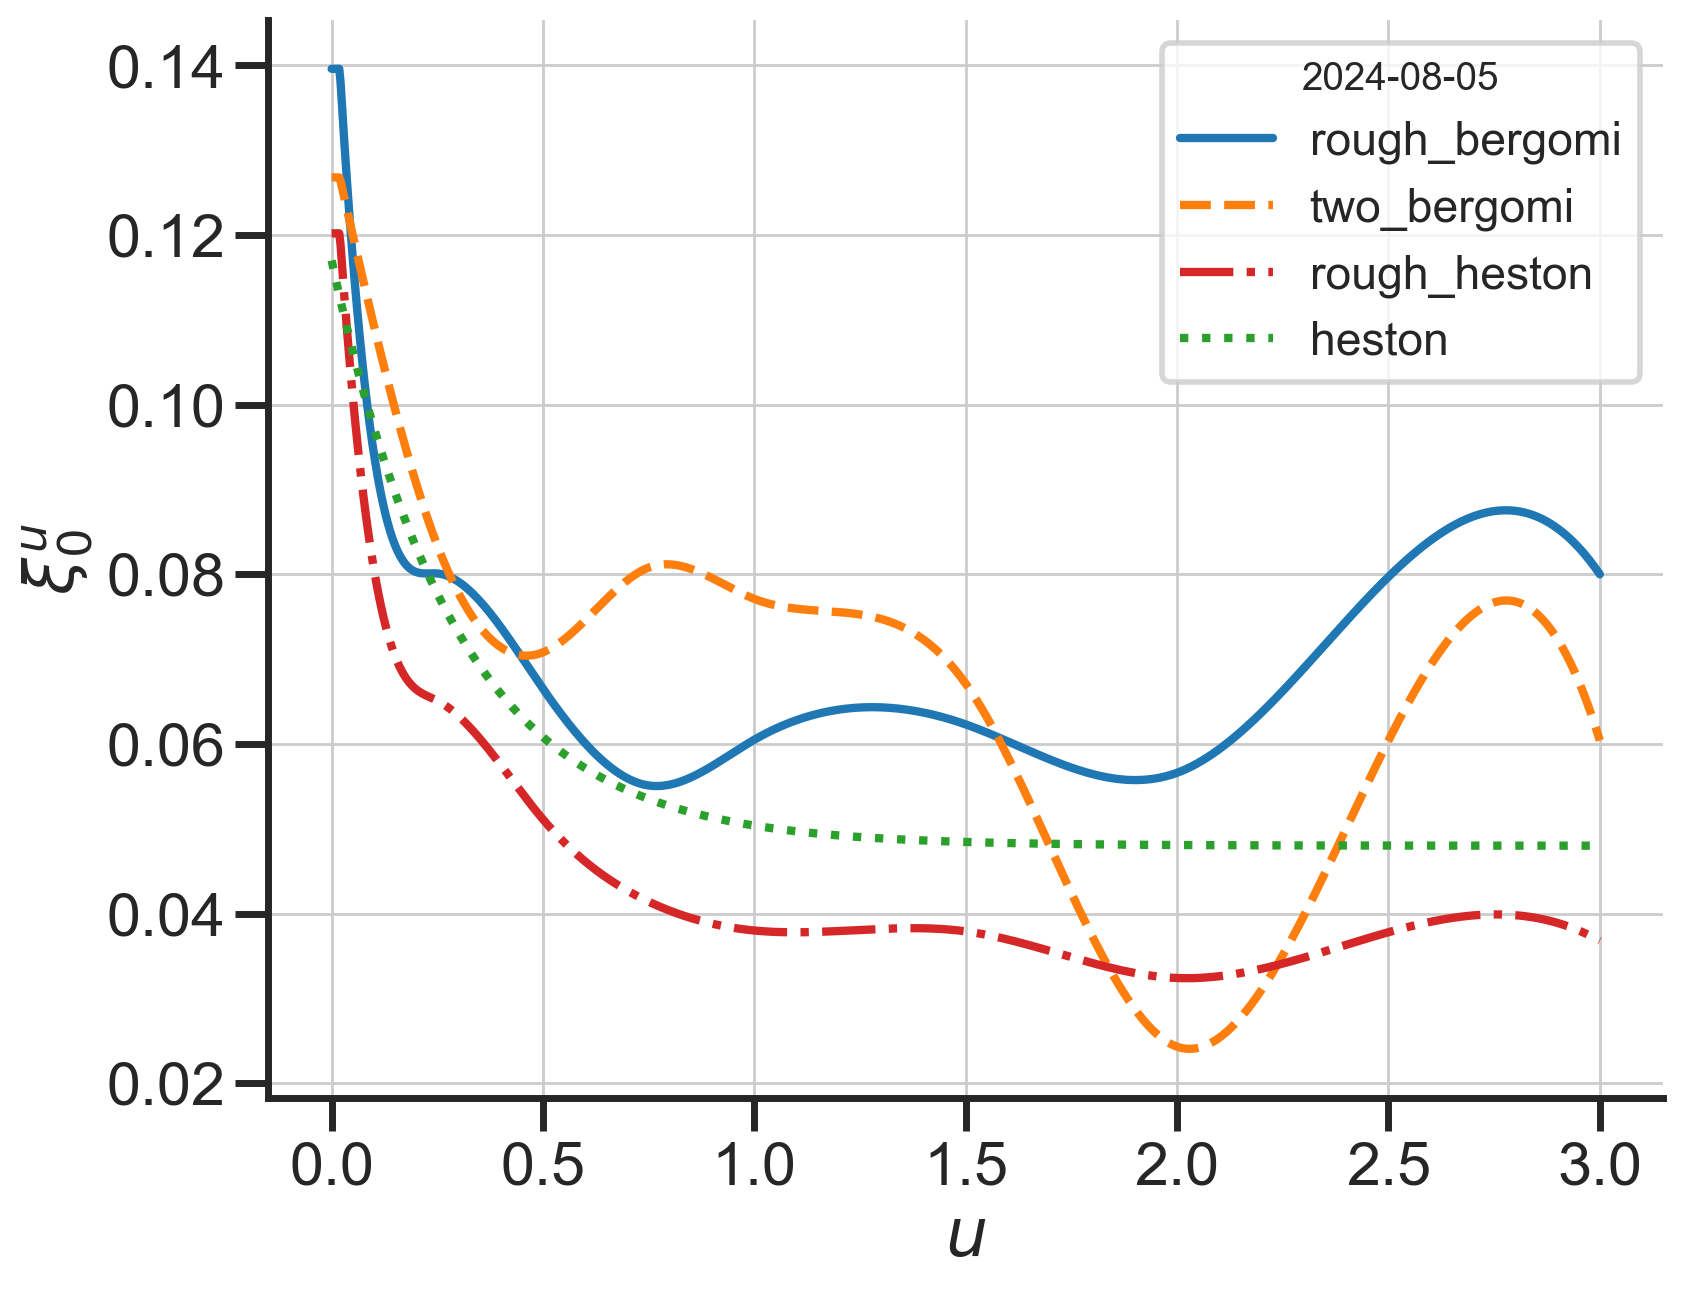

In [6]:
# plot forward variance curve xi0 for all models on the same plot at a given date

# pick up a date
date = DATES[1]
print(f"Plotting xi0 for {date}")

# maturities to evaluate xi0 on
Ts = np.linspace(0.0, 3.0, 1000)

models = ["rough_bergomi", "two_bergomi", "rough_heston"]
markers = ["-", "--", "-."]
colors = ["tab:blue", "tab:orange", "tab:red"]

kind = "cubic"  # interpolation method for xi0

fig, ax = plt.subplots()
for i, model in enumerate(models):
    xi0 = get_xi0_interpolator(date, model, kind=kind)
    ax.plot(Ts, xi0(Ts), markers[i], label=model, color=colors[i])
heston_model = HestonModel(get_params(date, "heston"))
ax.plot(Ts, heston_model.xi0(Ts), ":", label="heston", color="tab:green")
ax.legend(title=date)
ax.set_xlabel("$u$")
ax.set_ylabel(r"$\xi_0^u$")
if SAVEFIG:
    fig.savefig(f"figures/xi0/xi0_all_models_{date}.pdf", bbox_inches="tight")
plt.show()